 Clase 8 - Aprendizaje No Supervisado
Segmentación de Clientes con K-Means

Objetivo: Identificar segmentos latentes de clientes a partir de sus comportamientos de compra y uso del sitio, sin etiquetas previas.

Dataset: `dataset_segmentacion_clientes.csv`  
Variables utilizadas:
- `purchase_freq_month` — frecuencia de compras por mes
- `avg_basket_usd` — ticket promedio por compra en USD
- `time_on_site_min` — tiempo de permanencia en el sitio (minutos)
- `discount_sensitivity` — sensibilidad a descuentos (0 a 1)
- `returns_rate` — tasa de devoluciones (0 a 0.8)

 1. Importación de librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

#Graficosstil
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

 2. Carga y exploración del dataset

In [3]:
df = pd.read_csv('dataset_segmentacion_clientes.csv')
features = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min',
            'discount_sensitivity', 'returns_rate']
df = df[features].copy()

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (700, 5)


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,11.152508,181.300834,33.564036,1.000000,0.800000
1,12.053451,178.637272,35.432081,0.784974,0.000000
2,2.203006,450.185298,7.030757,0.898297,0.000000
3,4.233314,89.006342,10.834453,0.000000,0.800000
4,1.716799,449.773982,7.254548,0.000000,0.003279


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
dtypes: float64(5)
memory usage: 27.5 KB


In [5]:
df.describe().round(2)

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
count,700.00,700.00,700.00,700.00,700.00
mean,5.88,248.17,16.78,0.43,0.34
std,4.47,154.90,12.91,0.43,0.36
min,0.10,86.99,3.16,0.00,0.00
25%,2.28,90.77,6.60,0.00,0.00
50%,4.13,180.22,9.97,0.30,0.17
75%,11.21,449.72,34.34,1.00,0.80
max,14.60,452.97,38.35,1.00,0.80


 3. Visualización exploratoria de los datos

Antes de aplicar K-Means, exploramos la distribucion de cada variable y sus relaciones

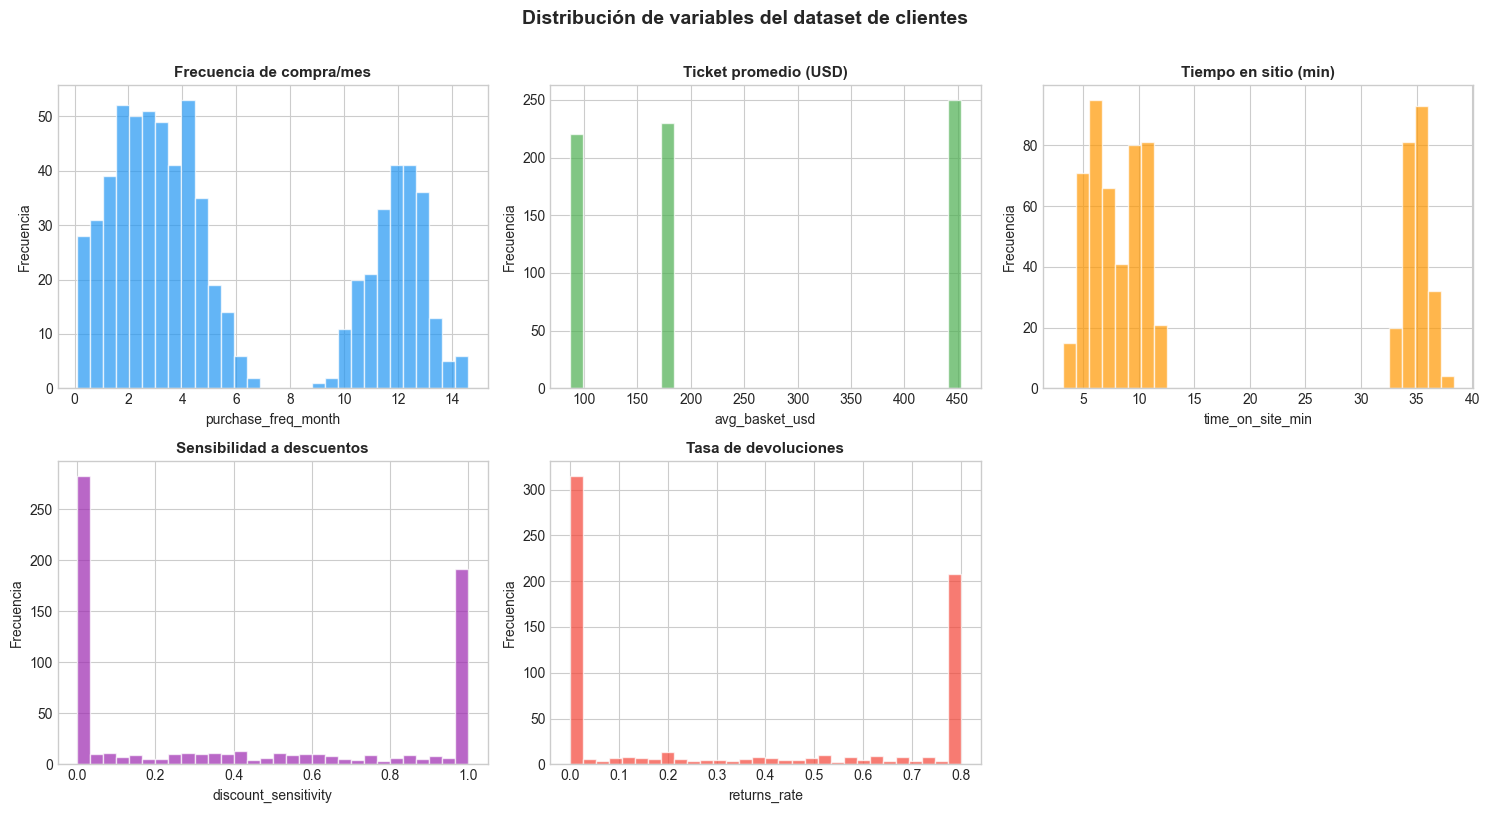

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
nombres = ['Frecuencia de compra/mes', 'Ticket promedio (USD)',
           'Tiempo en sitio (min)', 'Sensibilidad a descuentos', 'Tasa de devoluciones']

for i, (col, nombre, color) in enumerate(zip(features, nombres, colores)):
    axes[i].hist(df[col], bins=30, color=color, alpha=0.7, edgecolor='white')
    axes[i].set_title(nombre, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

axes[5].axis('off')
plt.suptitle('Distribución de variables del dataset de clientes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

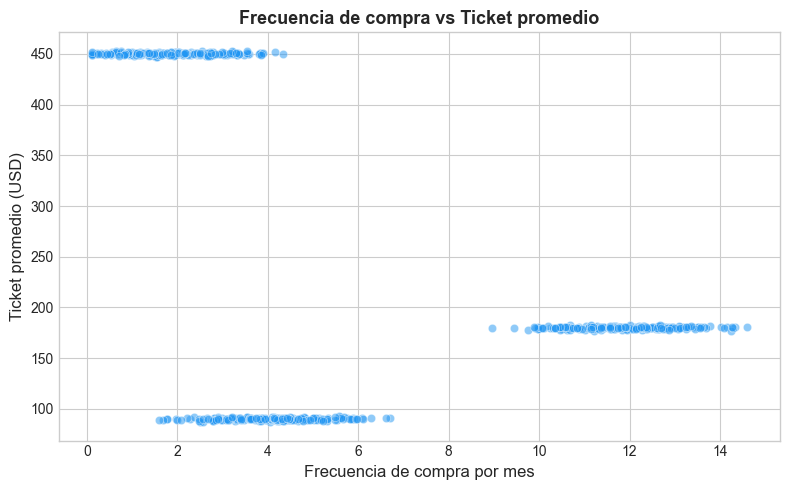

In [7]:
# scatterplot: Frecuencia vs Ticket promedio 
plt.figure(figsize=(8, 5))
plt.scatter(df['purchase_freq_month'], df['avg_basket_usd'],
            alpha=0.5, color='#2196F3', edgecolors='white', linewidth=0.5)
plt.xlabel('Frecuencia de compra por mes', fontsize=12)
plt.ylabel('Ticket promedio (USD)', fontsize=12)
plt.title('Frecuencia de compra vs Ticket promedio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

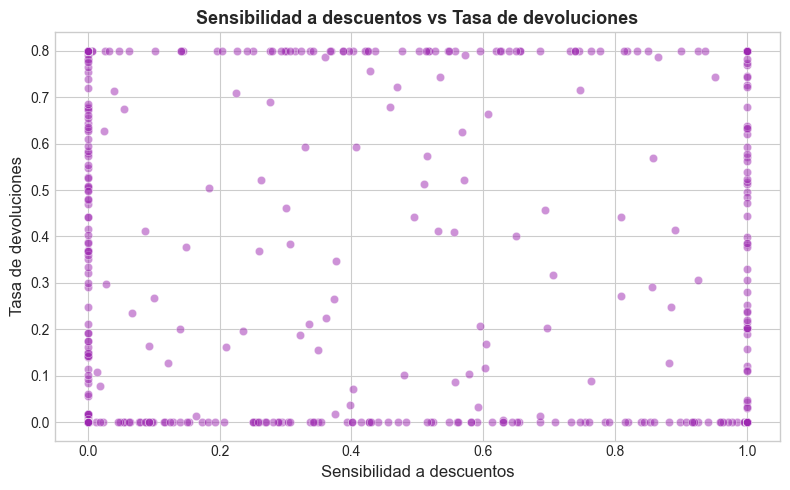

In [8]:
#scatterplot: Sensibilidad a descuentos vs Tasa de devoluciones
plt.figure(figsize=(8, 5))
plt.scatter(df['discount_sensitivity'], df['returns_rate'],
            alpha=0.5, color='#9C27B0', edgecolors='white', linewidth=0.5)
plt.xlabel('Sensibilidad a descuentos', fontsize=12)
plt.ylabel('Tasa de devoluciones', fontsize=12)
plt.title('Sensibilidad a descuentos vs Tasa de devoluciones', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

4. Escalado de variables

K-Means utiliza distancia euclidiana para agrupar los puntos, por eso es fundamental escalar las variables antes de aplicarlo. Sin escalado, variables con rangos grandes (como `avg_basket_usd` que va de ~87 a ~453 USD) ganarian sobre variables con rangos mas chicos (como `discount_sensitivity` de 0 a 1).

Usamos `StandardScaler` para llevar cada variable a media 0 y desvío estándar 1.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

#Salio?
df_scaled = pd.DataFrame(X_scaled, columns=features)
print("Estadísticas después del escalado:")
df_scaled.describe().round(3)

Estadísticas después del escalado:


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
count,700.000,700.000,700.000,700.000,700.000
mean,-0.000,-0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001
min,-1.293,-1.041,-1.056,-0.986,-0.946
25%,-0.805,-1.017,-0.789,-0.986,-0.946
50%,-0.390,-0.439,-0.528,-0.298,-0.482
75%,1.195,1.302,1.360,1.333,1.299
max,1.953,1.323,1.671,1.333,1.299


5. Método del Codo para elegir k

El método del codo consiste en entrenar K-Means para distintos valores de k y graficar la inercia. El mejor valor de K es en el punto donde la curva hace como un "codo" 

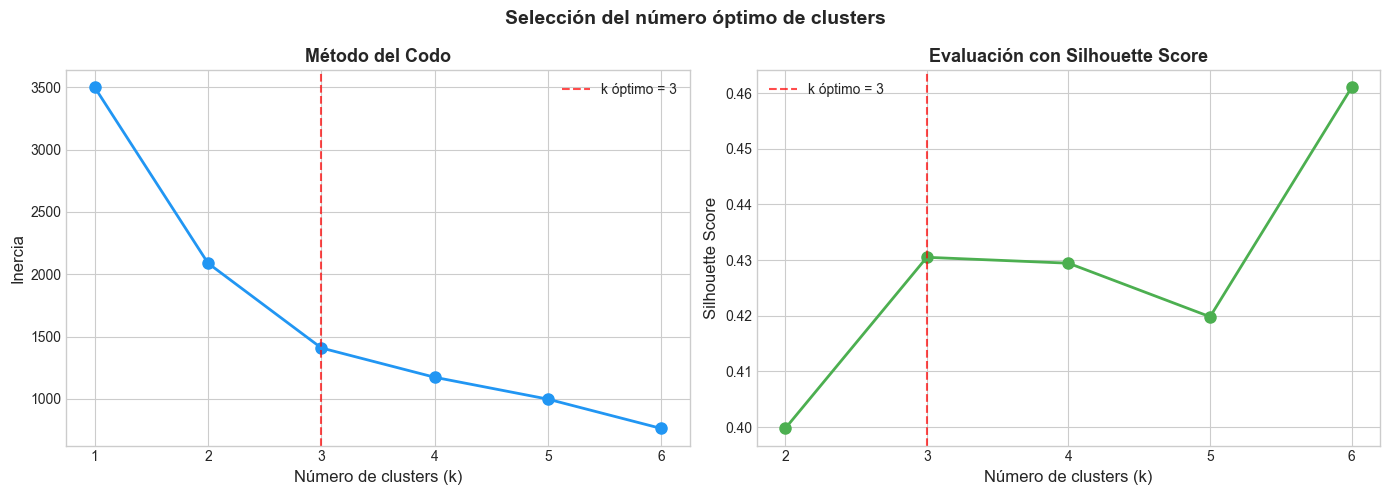


Resumen de métricas por k:
  k=2 → Inercia: 2088.9 | Silhouette: 0.3997
  k=3 → Inercia: 1408.7 | Silhouette: 0.4305
  k=4 → Inercia: 1173.4 | Silhouette: 0.4295
  k=5 → Inercia: 997.7 | Silhouette: 0.4198
  k=6 → Inercia: 762.5 | Silhouette: 0.4610


In [10]:
inercias = []
silhouette_scores = []
valores_k = range(2, 7)

for k in range(1, 7):
    modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    modelo.fit(X_scaled)
    inercias.append(modelo.inertia_)

for k in valores_k:
    modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = modelo.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

#Grafico del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 7), inercias, marker='o', color='#2196F3', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k óptimo = 3')
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, 7))

axes[1].plot(list(valores_k), silhouette_scores, marker='o', color='#4CAF50', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k óptimo = 3')
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Evaluación con Silhouette Score', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(valores_k))

plt.suptitle('Selección del número óptimo de clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nResumen de métricas por k:")
for i, k in enumerate(range(2, 7)):
    print(f"  k={k} → Inercia: {inercias[i+1]:.1f} | Silhouette: {silhouette_scores[i]:.4f}")

Interpretación del Método del Codo

Al observar la curva de inercia, se puede identificar un quiebre en k=3, a partir de ese punto, agregar más clusters no reduce significativamente la inercia. El Silhouette Score confirma que k=3 ofrece clusters bien diferenciados.

elegimos k=3 como número óptimo de clusters

 6. Entrenamiento del modelo K-Means con k=3

In [11]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',   # Inicialización inteligente de centroides
    n_init=10,          # Se ejecuta 10 veces con distintos centroides iniciales
    max_iter=300,       # Máximo de iteraciones por ejecución
    random_state=42     # Reproducibilidad
)

kmeans.fit(X_scaled)

df['cluster'] = kmeans.labels_

print(f"Inercia final: {kmeans.inertia_:.2f}")
print(f"\nCantidad de clientes por cluster:")
print(df['cluster'].value_counts().sort_index())

Inercia final: 1408.70

Cantidad de clientes por cluster:
cluster
0    230
1    250
2    220
Name: count, dtype: int64


 7. Visualización de los clusters

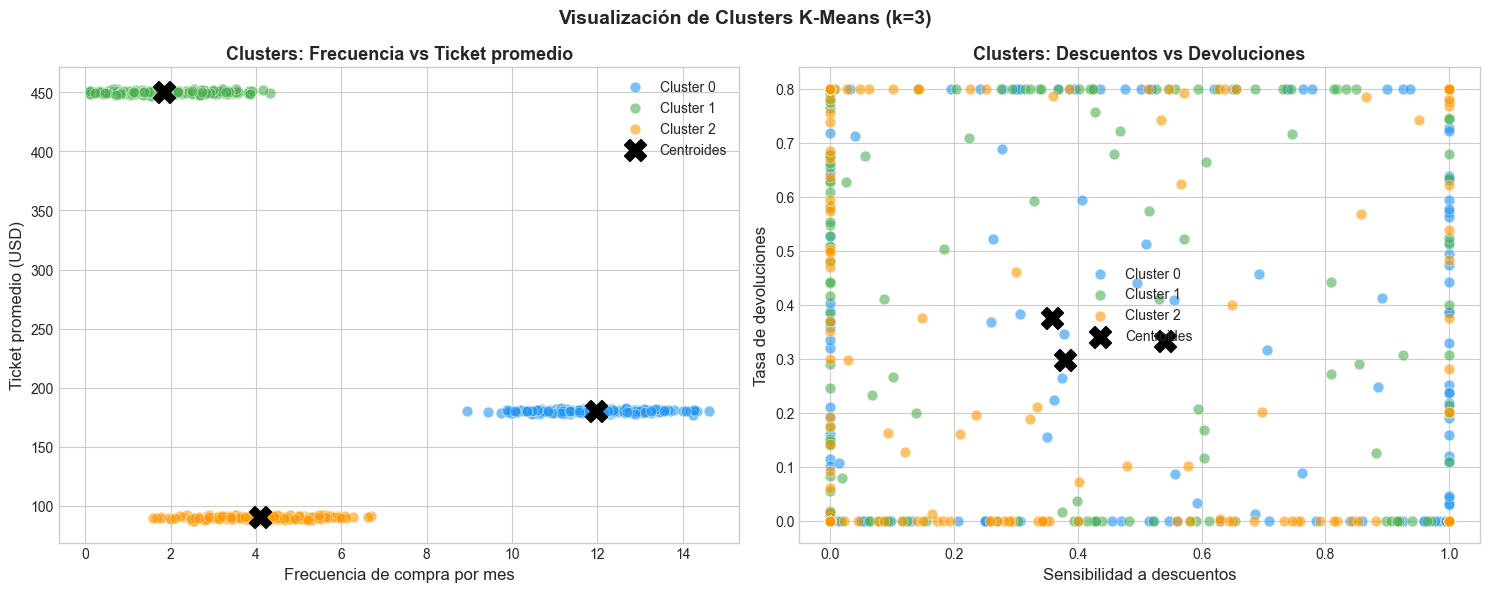

In [12]:
colores_cluster = ['#2196F3', '#4CAF50', '#FF9800']
nombres_cluster = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Frecuencia de compra vs Ticket promedio 
for c in range(3):
    mask = df['cluster'] == c
    axes[0].scatter(
        df.loc[mask, 'purchase_freq_month'],
        df.loc[mask, 'avg_basket_usd'],
        color=colores_cluster[c], alpha=0.6, label=nombres_cluster[c],
        edgecolors='white', linewidth=0.5, s=60
    )

#Centroides 
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(centroides[:, 0], centroides[:, 1],
                s=250, marker='X', c='black', zorder=5, label='Centroides')
axes[0].set_xlabel('Frecuencia de compra por mes', fontsize=12)
axes[0].set_ylabel('Ticket promedio (USD)', fontsize=12)
axes[0].set_title('Clusters: Frecuencia vs Ticket promedio', fontsize=13, fontweight='bold')
axes[0].legend()

#Gráfico 2: Sensibilidad a descuentos ves Tasa de devoluciones 
for c in range(3):
    mask = df['cluster'] == c
    axes[1].scatter(
        df.loc[mask, 'discount_sensitivity'],
        df.loc[mask, 'returns_rate'],
        color=colores_cluster[c], alpha=0.6, label=nombres_cluster[c],
        edgecolors='white', linewidth=0.5, s=60
    )
axes[1].scatter(centroides[:, 3], centroides[:, 4],
                s=250, marker='X', c='black', zorder=5, label='Centroides')
axes[1].set_xlabel('Sensibilidad a descuentos', fontsize=12)
axes[1].set_ylabel('Tasa de devoluciones', fontsize=12)
axes[1].set_title('Clusters: Descuentos vs Devoluciones', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Visualización de Clusters K-Means (k=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 8. Análisis de centroides y perfiles de clientes

In [13]:
# La media de cada variable x cluster
perfil = df.groupby('cluster')[features].mean().round(3)
perfil['n_clientes'] = df['cluster'].value_counts().sort_index()
print("Perfil de centroides por cluster:")
perfil

Perfil de centroides por cluster:


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,n_clientes
cluster,,,,,,
0,11.961,179.999,35.022,0.542,0.332,230
1,1.847,450.124,5.974,0.358,0.375,250
2,4.092,89.958,10.004,0.379,0.299,220


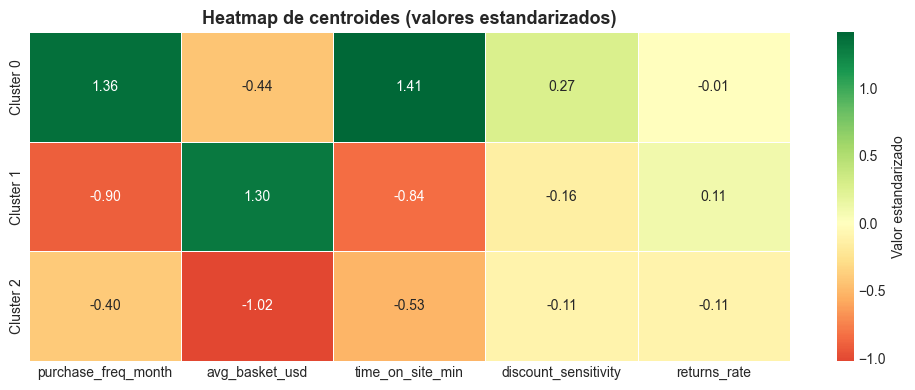

In [14]:
#Mapa de calor de centroides normalizados
centroides_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features,
    index=['Cluster 0', 'Cluster 1', 'Cluster 2']
)

plt.figure(figsize=(10, 4))
sns.heatmap(centroides_df, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'label': 'Valor estandarizado'})
plt.title('Heatmap de centroides (valores estandarizados)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

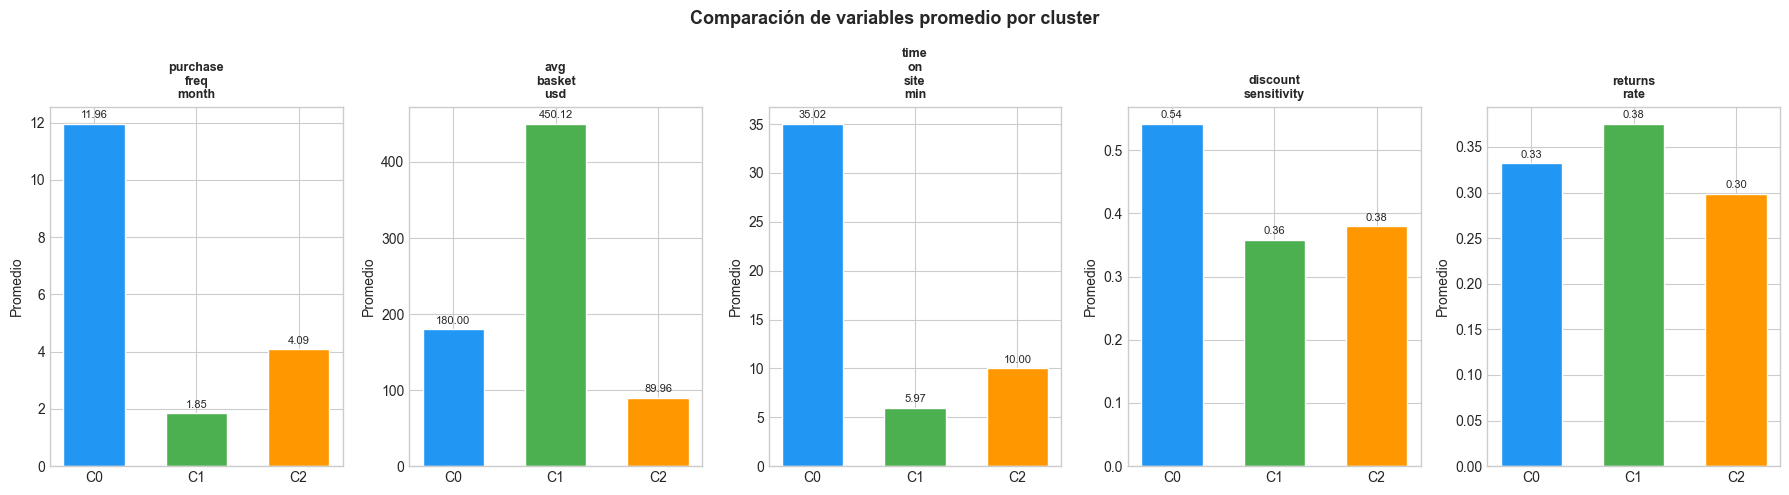

In [15]:
# Grafico de barras comparativo por cluster
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colores_cluster = ['#2196F3', '#4CAF50', '#FF9800']

for i, col in enumerate(features):
    vals = [df[df['cluster'] == c][col].mean() for c in range(3)]
    bars = axes[i].bar(['C0', 'C1', 'C2'], vals, color=colores_cluster, edgecolor='white', width=0.6)
    axes[i].set_title(col.replace('_', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Promedio')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparación de variables promedio por cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

9. Interpretación de los segmentos de clientes

A partir del análisis de los centroides, podemos describir los tres perfiles de clientes identificados:

Cluster 0 — "Compradores frecuentes sensibles al precio"
- Alta frecuencia de compra y ticket promedio bajo
- Alta sensibilidad a descuentos responden fuertemente a promociones
- Tiempo en sitio moderado
- Estrategia recomendada campañas de descuentos, programas de fidelidad, ofertas por volumen

Cluster 1 — "Compradores premium esporádicos"
- Baja frecuencia de compra pero ticket promedio alto
- Baja sensibilidad a descuentos: no necesitan incentivos de precio
- Tiempo en sitio corto (decisiones más directas)
- Estrategia recomendada: upselling de productos premium, experiencia de compra exclusiva

Cluster 2 — "Exploradores indecisos"
- Frecuencia y ticket moderados
- Alto tiempo en sitio y alta tasa de devoluciones
- Sensibilidad a descuentos media
- Estrategia recomendada mejorar experiencia de navegación, recomendaciones personalizadas, reducir fricciones en el proceso de compra

10. Predicción para nuevos clientes

In [16]:
nuevos_clientes = pd.DataFrame({
    'purchase_freq_month': [12.0, 1.5,  5.0],
    'avg_basket_usd':      [95.0, 440.0, 200.0],
    'time_on_site_min':    [20.0, 8.0,  35.0],
    'discount_sensitivity':[0.9,  0.1,   0.5],
    'returns_rate':        [0.1,  0.05,  0.6]
})

nuevos_scaled = scaler.transform(nuevos_clientes)
predicciones = kmeans.predict(nuevos_scaled)

nuevos_clientes['cluster_predicho'] = predicciones

nombres_perfil = {
    0: 'Comprador frecuente sensible al precio',
    1: 'Comprador premium esporádico',
    2: 'Explorador indeciso'
}
nuevos_clientes['perfil'] = nuevos_clientes['cluster_predicho'].map(nombres_perfil)

print("Clasificación de nuevos clientes:")
nuevos_clientes

Clasificación de nuevos clientes:


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,cluster_predicho,perfil
0,12.0,95.0,20.0,0.9,0.10,0,Comprador frecuente sensible al precio
1,1.5,440.0,8.0,0.1,0.05,1,Comprador premium esporádico
2,5.0,200.0,35.0,0.5,0.60,0,Comprador frecuente sensible al precio


11. Conclusiones

En esta actividad aplicamos el algoritmo K-Means para segmentar 700 clientes según su comportamiento de compra, sin utilizar etiquetas previas.

Pasos realizados:
1. Exploración y visualización del dataset
2. Escalado de variables con `StandardScaler` (necesario para K-Means)
3. Selección de k=3 mediante el método del codo y Silhouette Score
4. Entrenamiento del modelo y asignación de clusters
5. Análisis de centroides para describir los perfiles
6. Predicción para nuevos clientes

Hallazgos principales:
- K=3 resultó el número óptimo de clusters, confirmado por ambas métricas
- Se identificaron tres segmentos claramente diferenciados: compradores frecuentes/precio, premium/esporádicos y exploradores/indecisos
- Cada segmento sugiere estrategias de marketing distintas

Limitaciones de K-Means:
- Asume clusters esféricos y de tamaño similar
- Sensible a outliers y a la escala de las variables
- El número de clusters debe especificarse previamente